# USCASJ_uncertainty_viz.ipynb

USCASJ **daily** MLR prediction with an uncertainty band from the ranked pillow combinations.

Derived from `friant_uncertainty_viz.ipynb`, keeping only the individual-year comparison and
the peak-SWE pillow evaluation. The decade-panel figure and the availability analysis are
dropped -- there is one water year here, not 46.

Data layout differs from FRIANT. The daily runner derives its output directory from
`pillowImputation`, so files live at

    mlr_prediction/USCASJ/models/{STACK}/{SEASONAL}/ensemble_tidy_wy2026.csv

rather than FRIANT's `{VERSION}/season/`. `STACK` is the imputation *source*
(`COMMON_MASK` = pillow-based, `SNOWMODEL_IMPUTE` = SnowModel-grid-based); `_ens10` marks the
n_ensemble=10 run. Within a file, `isImpute` is a separate axis -- whether NaNs were filled
at all -- which is what `MODEL` selects.

Provenance: rank 1 in these files was verified against the published `prediction_mm` output
on all 30,720 date x band x mode checks, so the centre line is exactly what the pipeline
publishes. The band is new information.

## Inputs

In [9]:
WATER_YEAR = 2026
ELEV_BAND  = 'total'                 # 'total' or '<7000' ... '>12000'
MODEL      = 'predict NaNs'          # 'predict NaNs' | 'drop NaNs'
DATE       = '2026-04-17'            # peak SWE for WY2026 (254 mm, predict NaNs / total)

STACK      = 'COMMON_MASK_ens10'     # 'COMMON_MASK_ens10' | 'SNOWMODEL_IMPUTE_ens10'
SEASONAL   = 'season'                # 'season' | 'accum' | 'melt'

BAND       = 'p10_p90'               # 'p10_p90' | 'min_max' | 'sd'
N_RANKS    = 10
ADJ_R2_TOL = None                    # e.g. 0.05 -> drop members >0.05 below rank 1's adj_r2
ZOOM_DAYS  = 7

BASIN      = 'USCASJ'
SAVE_DIR   = None                    # e.g. '/home/rossamower/work/aso/figs' to write PNGs

## Load and setup

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

SRC = Path(f'/home/rossamower/work/aso/data/mlr_prediction/{BASIN}/models/{STACK}/{SEASONAL}')
f = SRC / f'ensemble_tidy_wy{WATER_YEAR}.csv'
if not f.exists():
    raise SystemExit(f'missing {f}')

e = pd.read_csv(f)
e['date'] = pd.to_datetime(e['date'])
# the daily runner does not write a water_year column (one WY per file); add it so the
# helper below can filter the same way the FRIANT notebook does.
e['water_year'] = WATER_YEAR
years = [WATER_YEAR]

print(f'{f}')
print(f'  {len(e):,} members | {e.date.dt.normalize().nunique()} dates '
      f'{e.date.min().date()} -> {e.date.max().date()}')
print(f'  ranks {sorted(e["rank"].unique())} | bands {len(e.elev_band.unique())} '
      f'| n_ensemble {sorted(e.n_ensemble.unique()) if "n_ensemble" in e else "n/a"}')
nfail = e['error'].notna().sum() if 'error' in e.columns else 0
print(f'  failed members: {nfail}')

# ---- style: categorical slots 1-2 of the validated palette ----
SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#8a8985'
MODE_COLORS = {'drop NaNs': '#2a78d6', 'predict NaNs': '#eb6834'}
MODE_FLAG   = {'drop NaNs': False, 'predict NaNs': True}
band_label  = {'p10_p90': f'p10-p90 of top-{N_RANKS}',
               'min_max': f'min-max of top-{N_RANKS}',
               'sd': 'rank1 +/- 1 sd'}[BAND]

# ASO flight dates -- where observed truth exists
try:
    ts = xr.open_dataset(f'/home/rossamower/work/aso/data/aso/{BASIN}/ASO_50M_SWE_TSERIES.nc')
    aso_dates = pd.DatetimeIndex(pd.to_datetime(ts.date.values)).normalize()
except Exception as exc:
    print('  ASO flight dates unavailable:', exc); aso_dates = pd.DatetimeIndex([])


def style(ax):
    ax.set_facecolor(SURFACE)
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(MUTED); ax.spines[s].set_linewidth(0.6)
    ax.grid(True, color=MUTED, alpha=0.20, linewidth=0.5); ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=9)


def ensemble_band(mode, elev_band, n_ranks=None, adj_r2_tol=None):
    """
    Collapse ranked members to one row per date: rank-1 plus a spread.

    Rank 1 is taken from the tidy file rather than joined from prediction_mm_*.csv, because
    the published file is int()-truncated -- mixing a truncated centre with an untruncated
    band can put the line marginally outside its own envelope.
    """
    n_ranks = N_RANKS if n_ranks is None else n_ranks
    adj_r2_tol = ADJ_R2_TOL if adj_r2_tol is None else adj_r2_tol
    d = e[(e.isImpute == MODE_FLAG[mode]) & (e.elev_band == elev_band)]
    d = d[d['rank'] <= n_ranks].dropna(subset=['pred_mm'])
    if adj_r2_tol is not None:
        d = d[d['adj_r2'] >= d.groupby('date')['adj_r2'].transform('max') - adj_r2_tol]
    if d.empty:
        return pd.DataFrame(columns=['rank1', 'lo', 'hi', 'sd', 'n'])
    g = d.groupby('date')['pred_mm']
    out = pd.DataFrame({'rank1': d[d['rank'] == 1].set_index('date')['pred_mm'],
                        'sd': g.std(), 'n': g.size(),
                        'p10': g.quantile(.10), 'p90': g.quantile(.90),
                        'min': g.min(), 'max': g.max()}).sort_index()
    out['lo'], out['hi'] = ({'p10_p90': (out.p10, out.p90),
                             'min_max': (out['min'], out['max'])}
                            .get(BAND, (out.rank1 - out.sd, out.rank1 + out.sd)))
    return out


def save(fig, name):
    if SAVE_DIR:
        p = Path(SAVE_DIR); p.mkdir(parents=True, exist_ok=True)
        fp = p / f'{BASIN}_wy{WATER_YEAR}_{STACK}_{SEASONAL}_{name}.png'
        fig.savefig(fp, dpi=200, facecolor=SURFACE, bbox_inches='tight')
        print('wrote', fp)

/home/rossamower/work/aso/data/mlr_prediction/USCASJ/models/COMMON_MASK_ens10/season/ensemble_tidy_wy2026.csv
  48,757 members | 320 dates 2025-10-02 -> 2026-08-17
  ranks [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] | bands 8 | n_ensemble [np.int64(10)]
  failed members: 0


## Figure -- Individual year comparison

`drop NaNs` and `predict NaNs` rank-1 predictions with their uncertainty bands, for the
selected elevation band.

The two are **not poolable into one band** -- they search different candidate pools
(`baseline_pils` vs `pils_removed`) against different training tables, and the impute mode
scores partly against synthetic predictors. Overlaying them shows how much of the
disagreement is shared versus mode-specific.

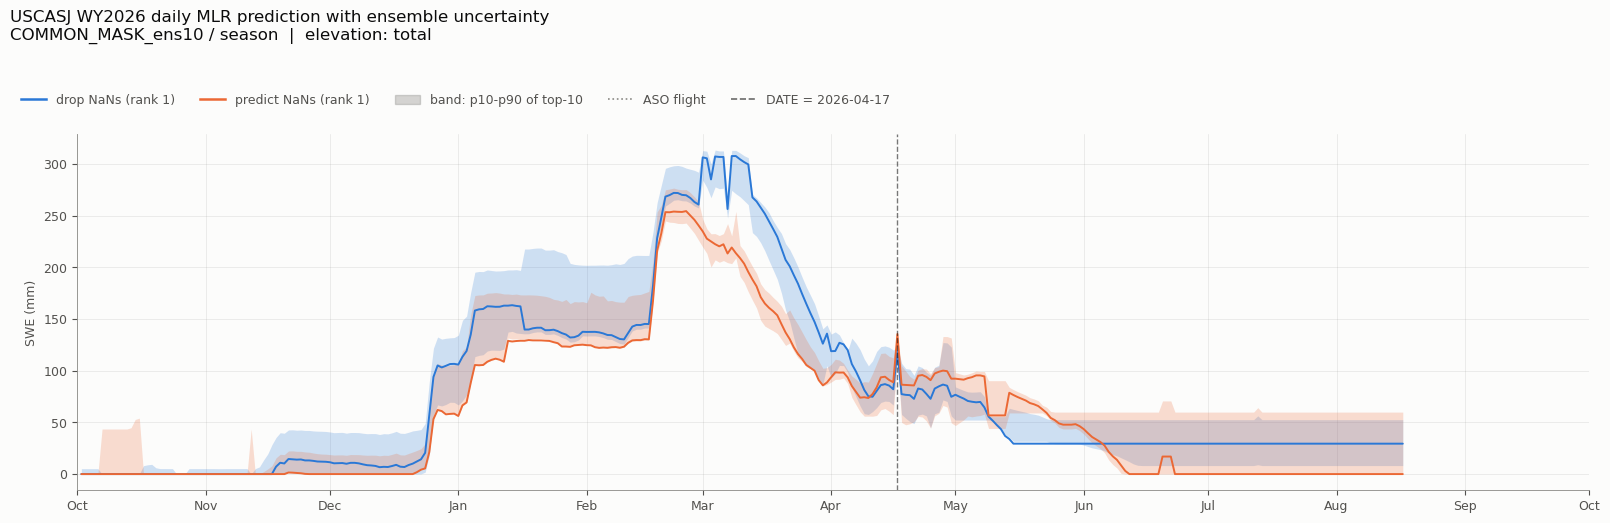

,mode,dates,peak_rank1_mm,peak_date,mean_sd_mm,mean_band_width_mm,median_sd_pct
0,drop NaNs,320,307.7,2026-03-08,20.4,41.0,36.0
1,predict NaNs,320,254.4,2026-02-25,18.4,36.8,19.8


In [11]:
fig, ax = plt.subplots(figsize=(16, 5.4), facecolor=SURFACE)
style(ax)

summary = []
for mode, colr in MODE_COLORS.items():
    a = ensemble_band(mode, ELEV_BAND)
    if a.empty:
        print(f'  no data for {mode}'); continue
    ax.fill_between(a.index, a.lo, a.hi, color=colr, alpha=0.22, lw=0, zorder=2)
    ax.plot(a.index, a.rank1, color=colr, lw=1.4, zorder=3, solid_capstyle='round')
    summary.append({'mode': mode, 'dates': len(a),
                    'peak_rank1_mm': round(a.rank1.max(), 1),
                    'peak_date': a.rank1.idxmax().date(),
                    'mean_sd_mm': round(a.sd.mean(), 1),
                    'mean_band_width_mm': round((a.hi - a.lo).mean(), 1),
                    'median_sd_pct': round((100 * a.sd / a.rank1.abs().replace(0, np.nan)).median(), 1)})

wy_lo, wy_hi = pd.Timestamp(f'{WATER_YEAR-1}-10-01'), pd.Timestamp(f'{WATER_YEAR}-10-01')
for x in aso_dates[(aso_dates >= wy_lo) & (aso_dates < wy_hi)]:
    ax.axvline(x, color=MUTED, lw=0.8, ls=':', zorder=1)
ax.axvline(pd.Timestamp(DATE), color=INK, lw=1.0, ls='--', alpha=0.55, zorder=4)
ax.set_xlim(wy_lo, wy_hi)
ax.set_ylabel('SWE (mm)', fontsize=9, color=INK2)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

handles = [plt.Line2D([], [], color=c, lw=1.8, label=f'{m} (rank 1)') for m, c in MODE_COLORS.items()]
handles += [plt.Rectangle((0, 0), 1, 1, color=MUTED, alpha=0.35, label=f'band: {band_label}'),
            plt.Line2D([], [], color=MUTED, ls=':', lw=1.2, label='ASO flight'),
            plt.Line2D([], [], color=INK, ls='--', lw=1.2, alpha=0.6, label=f'DATE = {DATE}')]
fig.subplots_adjust(left=0.05, right=0.995, top=0.76, bottom=0.10)
fig.suptitle(f'{BASIN} WY{WATER_YEAR} daily MLR prediction with ensemble uncertainty\n'
             f'{STACK} / {SEASONAL}  |  elevation: {ELEV_BAND}',
             x=0.008, ha='left', y=0.99, fontsize=12, color=INK)
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.008, 0.855), ncol=5,
           frameon=False, fontsize=9, labelcolor=INK2)
save(fig, 'year_comparison')
plt.show()

display(pd.DataFrame(summary))

### subFigure -- Peak SWE pillow uncertainty evaluation

Zoom to `DATE` +/- `ZOOM_DAYS` for the selected `MODEL`, then show which pillows each of the
top-10 rankings actually used.

The `adj R2` strip on the right is the ranking criterion. Read it before reading the band:
where the spread from rank 1 to rank 10 is small, the members are genuinely near-equivalent
and their disagreement *is* the uncertainty. Where it is large, the tail members are models
the selection criterion already rejected, and an unweighted band overstates uncertainty.

/tmp/ipykernel_46215/619894250.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0.006, 0, 1, 0.93])


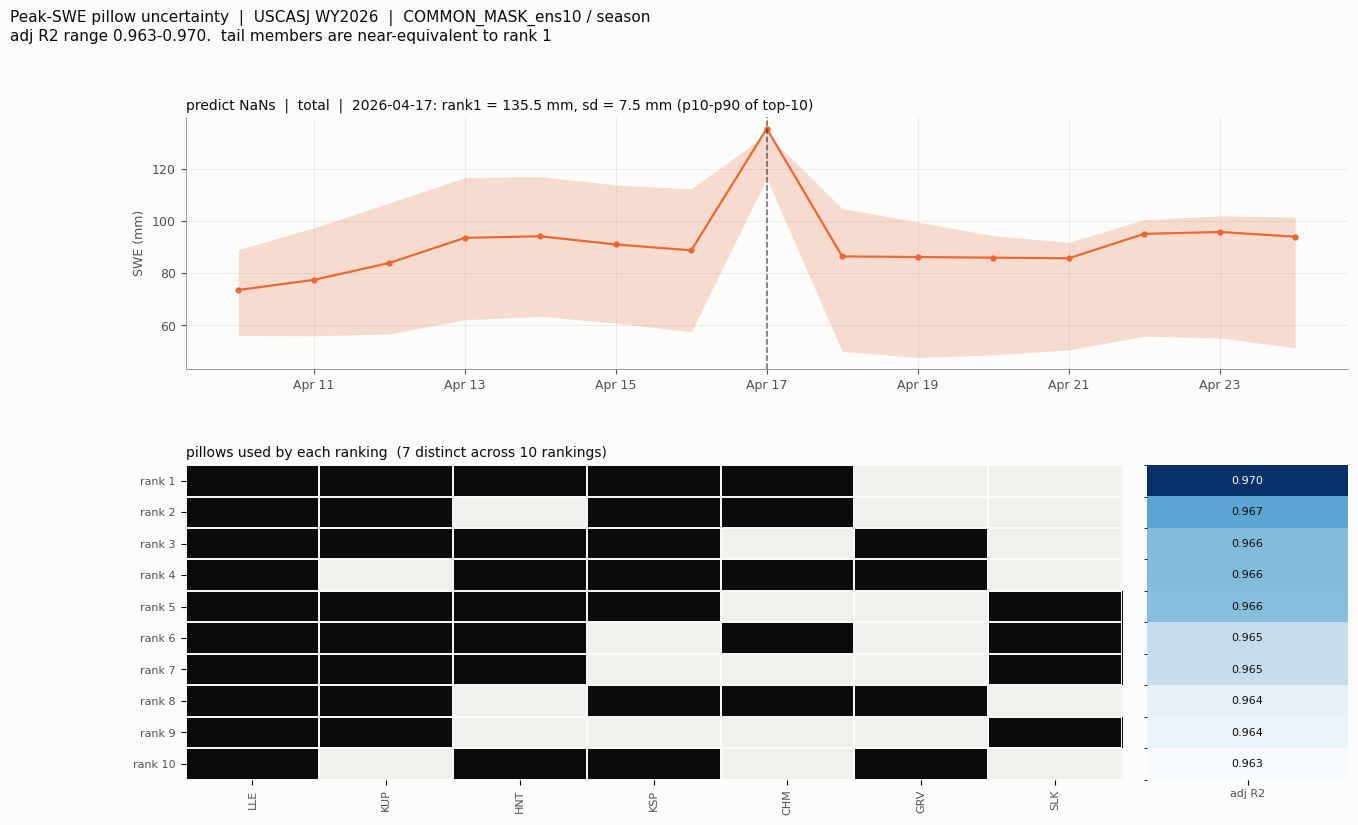

' rank  adj_r2             pillows  pred_mm  n_QA\n    1   0.970 CHM,HNT,KSP,KUP,LLE  135.481    13\n    2   0.967     CHM,KSP,KUP,LLE  121.268    13\n    3   0.966 GRV,HNT,KSP,KUP,LLE  124.616    13\n    4   0.966 CHM,GRV,HNT,KSP,LLE  116.863    13\n    5   0.966 HNT,KSP,KUP,LLE,SLK  129.107    13\n    6   0.965 CHM,HNT,KUP,LLE,SLK  133.115    13\n    7   0.965     HNT,KUP,LLE,SLK  129.724    13\n    8   0.964 CHM,GRV,KSP,KUP,LLE  122.655    13\n    9   0.964         KUP,LLE,SLK  119.134    13\n   10   0.963     GRV,HNT,KSP,LLE  111.957    13'

In [12]:
d0 = pd.Timestamp(DATE)
lo_d, hi_d = d0 - pd.Timedelta(days=ZOOM_DAYS), d0 + pd.Timedelta(days=ZOOM_DAYS)

sel = e[(e.isImpute == MODE_FLAG[MODEL]) & (e.elev_band == ELEV_BAND) &
        (e.date.dt.normalize() == d0)]
sel = sel[sel['rank'] <= N_RANKS].sort_values('rank')
if sel.empty:
    raise SystemExit(f'no members for {DATE} / {MODEL} / {ELEV_BAND}')

# pillow x rank occupancy, columns ordered by how often each pillow appears so the
# most-relied-on stations sit left rather than in alphabetical accident.
per_rank = {int(r['rank']): [p for p in str(r['pillows']).split(',') if p] for _, r in sel.iterrows()}
counts = pd.Series([p for v in per_rank.values() for p in v]).value_counts()
pillows_x, ranks_y = list(counts.index), sorted(per_rank)
occ = np.array([[1 if p in per_rank[rk] else 0 for p in pillows_x] for rk in ranks_y])
r2_col = sel.set_index('rank').loc[ranks_y, 'adj_r2'].astype(float).values

zoom = ensemble_band(MODEL, ELEV_BAND)
zoom = zoom[(zoom.index >= lo_d) & (zoom.index <= hi_d)]

fig = plt.figure(figsize=(15, 8.6), facecolor=SURFACE)
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.25],
                      width_ratios=[max(len(pillows_x), 6), 1.5], hspace=0.34, wspace=0.045)
ax_ts, ax_hm = fig.add_subplot(gs[0, :]), fig.add_subplot(gs[1, 0])
ax_r2 = fig.add_subplot(gs[1, 1], sharey=ax_hm)

style(ax_ts)
C = MODE_COLORS[MODEL]
ax_ts.fill_between(zoom.index, zoom.lo, zoom.hi, color=C, alpha=0.22, lw=0, zorder=2)
ax_ts.plot(zoom.index, zoom.rank1, color=C, lw=1.6, marker='o', ms=3.5, zorder=3)
ax_ts.axvline(d0, color=INK, lw=1.1, ls='--', alpha=0.6, zorder=4)
ax_ts.set_ylabel('SWE (mm)', fontsize=9, color=INK2)
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
r1 = float(zoom.rank1.reindex([d0]).iloc[0]) if d0 in zoom.index else float('nan')
sd = float(zoom.sd.reindex([d0]).iloc[0]) if d0 in zoom.index else float('nan')
ax_ts.set_title(f'{MODEL}  |  {ELEV_BAND}  |  {DATE}: rank1 = {r1:.1f} mm, sd = {sd:.1f} mm '
                f'({band_label})', fontsize=10, color=INK, loc='left', pad=6)

# binary presence/absence -> two flat tones, not a ramp; there is no magnitude here
ax_hm.imshow(occ, cmap=ListedColormap(['#f0efec', '#0b0b0b']), aspect='auto',
             vmin=0, vmax=1, interpolation='nearest')
ax_hm.set_xticks(range(len(pillows_x)))
ax_hm.set_xticklabels(pillows_x, rotation=90, fontsize=8, color=INK2)
ax_hm.set_yticks(range(len(ranks_y)))
ax_hm.set_yticklabels([f'rank {r}' for r in ranks_y], fontsize=8, color=INK2)
ax_hm.set_xticks(np.arange(-.5, len(pillows_x), 1), minor=True)
ax_hm.set_yticks(np.arange(-.5, len(ranks_y), 1), minor=True)
ax_hm.grid(which='minor', color=SURFACE, linewidth=1.4)
ax_hm.tick_params(which='minor', length=0)
for s in ax_hm.spines.values(): s.set_visible(False)
ax_hm.set_title(f'pillows used by each ranking  ({len(pillows_x)} distinct across '
                f'{len(ranks_y)} rankings)', fontsize=10, color=INK, loc='left', pad=6)

# adj R2 IS a magnitude -> one hue, light to dark
ax_r2.imshow(r2_col.reshape(-1, 1), cmap='Blues', aspect='auto',
             vmin=np.nanmin(r2_col), vmax=np.nanmax(r2_col), interpolation='nearest')
rng = max(np.nanmax(r2_col) - np.nanmin(r2_col), 1e-12)
for i, v in enumerate(r2_col):
    ax_r2.text(0, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
               color='#ffffff' if (v - np.nanmin(r2_col)) / rng > 0.55 else INK)
ax_r2.set_xticks([0]); ax_r2.set_xticklabels(['adj R2'], fontsize=8, color=INK2)
ax_r2.tick_params(axis='y', length=0, labelleft=False)
for s in ax_r2.spines.values(): s.set_visible(False)

drop = float(np.nanmax(r2_col) - np.nanmin(r2_col))
note = ('  tail members are near-equivalent to rank 1' if drop < 0.05 else
        f'  CAUTION: adj R2 falls {drop:.3f} from rank 1 to rank {ranks_y[-1]} -- the tail '
        'members are models the criterion rejected, so an unweighted band overstates uncertainty')
fig.suptitle(f'Peak-SWE pillow uncertainty  |  {BASIN} WY{WATER_YEAR}  |  {STACK} / {SEASONAL}\n'
             f'adj R2 range {np.nanmin(r2_col):.3f}-{np.nanmax(r2_col):.3f}.{note}',
             x=0.008, ha='left', y=1.005, fontsize=11, color=INK)
fig.tight_layout(rect=[0.006, 0, 1, 0.93])
save(fig, 'peak_swe_pillow_uncertainty')
plt.show()

display(sel[['rank', 'adj_r2', 'pillows', 'pred_mm', 'n_QA']].round(3).to_string(index=False))